# 🪨📄✂️ Rock-Paper-Scissors Behavior Cloning
### A transformer that predicts the next move

## 1. Setup

### Imports

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm
from collections import Counter


### Constants and parameters

In [2]:
SEED = 31416
MOVE={'rock':0,'paper':1,'scissors':2, 'none': -1}
NAMES = ['rock', 'paper', 'scissors']
SYM = ['🪨', '📄', '✂️']
OUTCOME = {'loss': -1, 'tie': 0, 'win': 1}
OUTCOME_NAMES = ['loss', 'tie', 'win']
POINTS = {'loss': -1, 'tie': 0, 'win': 3}

# location of the data
# from  Brockbank & Vul (UC San Diego), *"Formalizing Opponent Modeling with the Rock, Paper, Scissors Game"* (Games, 2021). 
# 62 dyads = **124 people**, each playing up to **300 rounds** of RPS against another human, ~36,000 throws total. 
# Every row records one person's move and whether they won/lost/tied. Openly licensed on GitHub.
URL_MAIN="https://raw.githubusercontent.com/erik-brockbank/rps-games-analysis/main/data/rps_v1_data.csv"
URL_ALT ="https://raw.githubusercontent.com/erik-brockbank/rps-games-analysis/master/data/rps_v1_data.csv"

model_params = {
    'context_length': 8, # how many past rounds the model can see
    'batch_size': 64,
    'd_embed': 96,
    'n_head': 4,
    'n_layer': 2,
    'dropout': 0.2,
    'learning_rate': 3e-3,
    'weight_decay': 1e-2,
    'n_epochs': 30,
    'd_input': None, # per-round feature dim (moves/outcomes/totals), set after dataset is created
    'n_player_ids': None, # to be set after dataset is created
    'd_output': len(NAMES), # 3-class one-hot for the next move
    'scheduler_type': 'OneCycleLR', # learning rate scheduler to use during training
}

lr_scheduler_params = {
    'max_lr': 3e-3,
    'epochs': model_params['n_epochs'],
    'pct_start': 0.3,
    'anneal_strategy': 'cos',
    'div_factor': 25.0,
    'final_div_factor': 1e4,    
}

val_fraction = .1 # fraction of games to hold out for validation

torch.manual_seed(SEED)
np.random.seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)


device: cpu


/home/bransonk@hhmi.org/miniforge3/envs/tmp-data-format/lib/python3.13/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 2. Load and process the data

### Load the data

In [3]:
# load the data

try:
    df = pd.read_csv(URL_MAIN)
except Exception:
    df = pd.read_csv(URL_ALT)

# show the first few rows of the data
df.head(10)


,game_id,round_index,player_id,round_begin_ts,player_move,player_rt,player_outcome,player_outcome_viewtime,player_points,player_total
0,ef8a8513-5542-4c94-bfc4-fecbfb74d540,1,4df9aef5-2ea7-46b0-ace9-5d19c4532c03,1578956454756,paper,2691,loss,2918,-1,0
1,ef8a8513-5542-4c94-bfc4-fecbfb74d540,1,33261505-3a41-47b5-b3db-83cb6aeb1a9f,1578956454756,scissors,1908,win,2674,3,0
2,ef8a8513-5542-4c94-bfc4-fecbfb74d540,2,4df9aef5-2ea7-46b0-ace9-5d19c4532c03,1578956460386,rock,1888,loss,3553,-1,-1
3,ef8a8513-5542-4c94-bfc4-fecbfb74d540,2,33261505-3a41-47b5-b3db-83cb6aeb1a9f,1578956460386,paper,1292,win,1869,3,3
4,ef8a8513-5542-4c94-bfc4-fecbfb74d540,3,4df9aef5-2ea7-46b0-ace9-5d19c4532c03,1578956465842,scissors,1793,win,3684,3,-2
5,ef8a8513-5542-4c94-bfc4-fecbfb74d540,3,33261505-3a41-47b5-b3db-83cb6aeb1a9f,1578956465842,paper,1529,loss,957,-1,6
6,ef8a8513-5542-4c94-bfc4-fecbfb74d540,4,4df9aef5-2ea7-46b0-ace9-5d19c4532c03,1578956471330,paper,1465,win,2144,3,1
7,ef8a8513-5542-4c94-bfc4-fecbfb74d540,4,33261505-3a41-47b5-b3db-83cb6aeb1a9f,1578956471330,rock,3458,loss,2653,-1,5
8,ef8a8513-5542-4c94-bfc4-fecbfb74d540,5,4df9aef5-2ea7-46b0-ace9-5d19c4532c03,1578956477470,rock,1883,win,2206,3,4
9,ef8a8513-5542-4c94-bfc4-fecbfb74d540,5,33261505-3a41-47b5-b3db-83cb6aeb1a9f,1578956477470,scissors,2428,loss,2379,-1,4


### Reformat and clean the data

In [4]:
# class to hold data from each game
class GameData:
    """
    GameData
    Holds data for one game (two players, multiple rounds) in a convenient format for sequence modeling.
    Initializes from a dataframe containing all rows for that game, and extracts the player ids, 
    moves, outcomes, and total points into numpy arrays.
    self.player_ids is the array of player ids (shape (2,))
    self.moves[round, player] is the move that the player made in that round
    self.outcomes[round, player] is the outcome (loss=-1, tie=0, win=1) for that player in that round
    self.total[round, player] is the total points that player had AFTER that round 
    (i.e. the cumulative sum of outcomes up to and including that round)    
    Arrays are shaped (nrounds, 2) so that flattening interleaves players within a round:
    ((round0,player0), (round0,player1), (round1,player0), (round1,player1), ...).
    """

    player_ids: np.ndarray  # shape (2,), player_ids[player]
    moves: np.ndarray  # shape (nrounds, 2), moves[round, player] (rock=0, paper=1, scissors=2)
    outcomes: np.ndarray  # shape (nrounds, 2), outcomes[round, player] (loss=-1, tie=0, win=1)
    total: np.ndarray  # shape (nrounds, 2), total[round, player], total points after this round
    
    def __init__(self, df):
        self.player_ids = np.unique(df['player_id']) # player 0 and 1
        nrounds = np.max(df['round_index']) # round_index is 1-indexed
        self.moves = -np.ones((nrounds, 2), dtype=int)  # moves[round, player]
        self.outcomes = np.zeros((nrounds, 2), dtype=int)  # outcomes[round, player]
        points = np.zeros((nrounds, 2), dtype=int) # points gained each round (player_points)
        for row in df.itertuples():
            round_index = row.round_index - 1  # convert to 0-indexed
            player_idx = np.where(self.player_ids == row.player_id)[0][0]
            if row.player_move not in MOVE or row.player_outcome not in OUTCOME:
                print(f"  Warning: unrecognized move or outcome in round {round_index}, player {player_idx}: move={row.player_move}, outcome={row.player_outcome}")
                continue  # skip if move is not recognized
            self.moves[round_index, player_idx] = MOVE[row.player_move]
            self.outcomes[round_index, player_idx] = OUTCOME[row.player_outcome]            
            points[round_index, player_idx] = row.player_points
        # drop any rounds where move is none
        keep = ~np.any(self.moves==-1,axis=1)
        if ~np.all(keep):
            print(f"  Warning: dropping {np.sum(~keep)} rounds with none or unrecognized moves")
        self.moves = self.moves[keep]
        self.outcomes = self.outcomes[keep]
        points = points[keep]
        
        # compute total points after each round by taking the cumulative sum of points gained each round
        self.total = np.cumsum(points, axis=0)
    
    @classmethod
    def from_arrays(cls, moves, outcomes, total, player_ids=None):
        """Build a GameData directly from arrays (bypasses __init__, which expects a dataframe)."""
        g = cls.__new__(cls)
        g.player_ids = np.array([0, 1]) if player_ids is None else np.asarray(player_ids)
        g.moves    = np.asarray(moves,    dtype=int)   # (nrounds, 2)
        g.outcomes = np.asarray(outcomes, dtype=int)   # (nrounds, 2)
        g.total    = np.asarray(total,    dtype=int)   # (nrounds, 2)
        return g
    
    def __len__(self):
        return self.moves.shape[0]  # number of rounds
    
    def show(self, start=0, end=None, max_rounds=50, style=True):
        """Render the game as a table: columns = rounds, row 0 = player 0's move,
        row 1 = player 1's move (as symbols), row 2 = winner (-1 player 0, 0 tie, +1 player 1).
        Returning the result auto-displays it in a notebook; pass style=False for a plain DataFrame."""
        n = len(self)
        end = n if end is None else min(end, n)
        if max_rounds is not None:
            end = min(end, start + max_rounds)   # cap width so long games stay readable
        cols = list(range(start, end))
        # outcomes[:, 1] is already +1 when player 1 wins, -1 when player 0 wins, 0 on a tie
        winner = [int(self.outcomes[t, 1]) for t in cols]
        tbl = pd.DataFrame(
            [[SYM[self.moves[t, 0]] for t in cols],
             [SYM[self.moves[t, 1]] for t in cols],
             winner,
             [self.total[t, 0] for t in cols],
             [self.total[t, 1] for t in cols]],
            index=['player 0', 'player 1', 'winner', 'total 0', 'total 1'],
            columns=cols,
        )
        tbl.columns.name = 'round'
        if not style:
            return tbl
        def color_winner(v):
            return {-1: 'background-color:#f8d7da',   # player 0 won
                     1: 'background-color:#d4edda',   # player 1 won
                     0: 'background-color:#eeeeee'}.get(v, '')   # tie
        return tbl.style.map(color_winner, subset=pd.IndexSlice[['winner'], :])

# convert to dict of ndarrays, where each entry of the dict corresponds to a game
games = {}
game_ids = np.unique(df['game_id'])
for game_id in game_ids:
    idx = df['game_id'] == game_id
    print(f"== Game {game_id} ==")
    games[game_id] = GameData(df[idx])
    print(f"  N. rounds = {len(games[game_id])}")

player_ids = sorted({pid for g in games.values() for pid in g.player_ids})
player_id_to_index = {pid: i for i, pid in enumerate(player_ids)}
    
# split into train and val sets
n_games = len(games)

print(f'Total number of games: {n_games}')
print(f'Total number of players: {len(player_ids)}')

game_id = list(games.keys())[0]
print(f"Example game id: {game_id}")
games[game_id].show()


== Game 0283f6be-802c-4f51-bd49-7ddbc6d9dc84 ==
  N. rounds = 295
== Game 03d3902a-3073-488a-b96f-b846d7a6f2ec ==
  N. rounds = 300
== Game 0c38a6ee-ed33-443c-b240-bef3802676ad ==
  N. rounds = 299
== Game 0cea1687-3a04-43a7-b6b1-7f12f84db3a2 ==
  N. rounds = 300
== Game 0dafca5d-8b3b-4715-a3d9-dac771104d80 ==
  N. rounds = 300
== Game 1319391d-063a-4e04-b01e-d3cf0fd106a1 ==
  N. rounds = 300
== Game 138c2f27-3a67-4b44-9ebe-1418559ffdcc ==
  N. rounds = 300
== Game 1b4ff0c2-2150-47bd-bea7-cae8c55bf89c ==
  N. rounds = 52
== Game 1d738b11-5151-4ebe-beb1-c6f435b7483c ==
  N. rounds = 300
== Game 23460664-eee3-45dd-997c-49595d3aeb2e ==
  N. rounds = 299
== Game 239534b4-e035-48a0-af0b-414a97bcc631 ==
  N. rounds = 300
== Game 24b49199-9ed8-492a-ab75-7497e037c496 ==
  N. rounds = 298
== Game 2fa0db25-12b6-4b92-956f-816fb7f42326 ==
  N. rounds = 299
== Game 2fab6d58-8842-4862-96db-451b64b23979 ==
  N. rounds = 300
== Game 3263e845-4135-4112-a68c-6a731963d9cf ==
  N. rounds = 298
== Game 361

round,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
player 0,✂️,📄,✂️,✂️,✂️,✂️,📄,📄,✂️,📄,✂️,📄,📄,📄,🪨,✂️,✂️,🪨,📄,✂️,🪨,📄,📄,🪨,✂️,📄,🪨,📄,📄,✂️,📄,✂️,📄,✂️,🪨,📄,🪨,✂️,📄,📄,✂️,📄,✂️,📄,📄,✂️,📄,✂️,🪨,📄
player 1,✂️,🪨,🪨,✂️,📄,✂️,🪨,📄,✂️,🪨,🪨,📄,✂️,📄,📄,✂️,📄,✂️,✂️,🪨,✂️,📄,✂️,📄,✂️,✂️,📄,✂️,📄,📄,📄,✂️,✂️,📄,✂️,📄,📄,📄,📄,🪨,📄,📄,✂️,📄,✂️,🪨,✂️,📄,✂️,📄
winner,0,-1,1,0,-1,0,-1,0,0,-1,1,0,1,0,1,0,-1,-1,1,1,-1,0,1,1,0,1,1,1,0,-1,0,0,1,-1,-1,0,1,-1,0,-1,-1,0,0,0,1,1,1,-1,-1,0
total 0,0,3,2,2,5,5,8,8,8,11,10,10,9,9,8,8,11,14,13,12,15,15,14,13,13,12,11,10,10,13,13,13,12,15,18,18,17,20,20,23,26,26,26,26,25,24,23,26,29,29
total 1,0,-1,2,2,1,1,0,0,0,-1,2,2,5,5,8,8,7,6,9,12,11,11,14,17,17,20,23,26,26,25,25,25,28,27,26,26,29,28,28,27,26,26,26,26,29,32,35,34,33,33


### Explore data

62 games, 35938 throws, 52-300 rounds/game


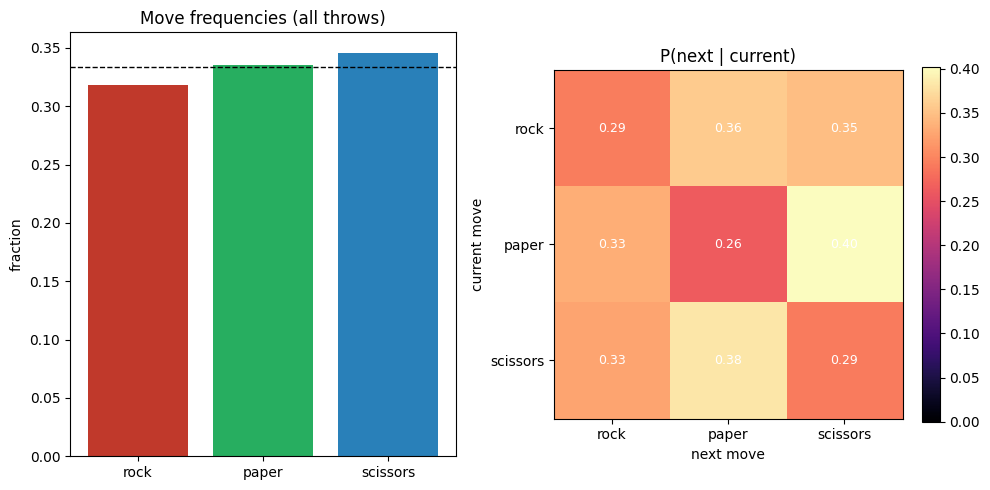

In [5]:
# plot some summary statistics of the data
all_moves    = np.concatenate([g.moves.ravel()    for g in games.values()])
all_outcomes = np.concatenate([g.outcomes.ravel() for g in games.values()])
rounds_per_game = np.array([len(g) for g in games.values()])
print(f"{len(games)} games, {len(all_moves)} throws, "
      f"{rounds_per_game.min()}-{rounds_per_game.max()} rounds/game")

# order-1 transition counts P(next move | current move), pooled over players & games
trans = np.zeros((3, 3))
for g in games.values():
    for p in range(2):
        for a, b in zip(g.moves[:-1, p], g.moves[1:, p]):
            trans[a, b] += 1
trans = trans / trans.sum(1, keepdims=True)

MCOLORS = ['#c0392b', '#27ae60', '#2980b9']        # rock / paper / scissors
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# (1) move frequencies -- look for the rock bias
ax[0].bar(NAMES, np.bincount(all_moves, minlength=3) / len(all_moves), color=MCOLORS)
ax[0].axhline(1/3, ls='--', c='k', lw=1, label='uniform (1/3)')
ax[0].set_title('Move frequencies (all throws)'); ax[0].set_ylabel('fraction');

# (2) order-1 transition matrix -- stickiness shows up on the diagonal
im = ax[1].imshow(trans, cmap='magma', vmin=0, vmax=trans.max())
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(NAMES)
ax[1].set_yticks(range(3)); ax[1].set_yticklabels(NAMES)
ax[1].set_xlabel('next move'); ax[1].set_ylabel('current move')
ax[1].set_title('P(next | current)')
for r in range(3):
    for c in range(3):
        ax[1].text(c, r, f'{trans[r, c]:.2f}', ha='center', va='center',
                      color='white' if trans[r, c] < 0.5 else 'black', fontsize=9)
fig.colorbar(im, ax=ax[1], fraction=0.046)
fig.tight_layout()

### Split games into training and val

Since each player only plays in one game, start of every game is training, end is validation

In [6]:
def split_games_temporally(games, context_length, val_fraction=val_fraction):
    train_data = {}
    val_data = {}

    for game_id, g in games.items():
        n = len(g)

        # split_round = first original round that belongs to validation targets
        split_round = int((1 - val_fraction) * n)

        # need at least one train target and one val target
        split_round = max(context_length + 1, split_round)
        split_round = min(n - 1, split_round)

        # training chunk: rounds [0, ..., split_round-1]
        train_data[game_id] = GameData.from_arrays(
            g.moves[:split_round],
            g.outcomes[:split_round],
            g.total[:split_round],
            player_ids=g.player_ids,
        )

        # validation chunk starts context_length rounds earlier so the first
        # val example has enough history to predict original round split_round
        val_start = split_round - context_length
        val_data[game_id] = GameData.from_arrays(
            g.moves[val_start:],
            g.outcomes[val_start:],
            g.total[val_start:],
            player_ids=g.player_ids,
        )

    return train_data, val_data

train_data, val_data = split_games_temporally(games,context_length=model_params['context_length'],val_fraction=val_fraction)

print(f"Total training moves: {sum(2*len(g) for g in train_data.values())}")
print(f"Total validation moves: {sum(2*len(g) for g in val_data.values())}")


Total training moves: 32332
Total validation moves: 4598


### Helper functions

In [7]:
# helper functions

def beats(move_in):  
    """Returns the move that beats move_in. If move_in is an array, returns an array of the same shape."""
    isscalar = np.isscalar(move_in)
    if isinstance(move_in, torch.Tensor):
        move_out = torch.zeros_like(move_in,dtype=torch.long)
    else:
        if not isinstance(move_in, np.ndarray):
            move_in = np.asarray(move_in, dtype=int)
        move_out = np.zeros_like(move_in, dtype=int)
    move_out[move_in == MOVE['rock']] = MOVE['paper']
    move_out[move_in == MOVE['paper']] = MOVE['scissors']
    move_out[move_in == MOVE['scissors']] = MOVE['rock']
        
    if isscalar:
        move_out = move_out.item()  # convert back to scalar if input was scalar
        
    return move_out

def winner(move_self, move_opp):
    """
    Returns self_outcome, opp_outcome, where each is 1 if that player wins, -1 if that player loses, 0 if tie. 
    move_self and move_opp are in [0,1,2] for rock/paper/scissors. If move_self and move_opp are arrays, returns arrays of the same shape.
    """
    self_isscalar = np.isscalar(move_self)
    opp_isscalar = np.isscalar(move_opp)
    if isinstance(move_self, torch.Tensor):
        self_outcome = torch.full_like(move_self, OUTCOME['win'])
    else:
        move_self = np.asarray(move_self, dtype=int)
        self_outcome = np.full_like(move_self, OUTCOME['win'])
    if isinstance(move_opp, torch.Tensor):
        opp_outcome = torch.full_like(move_opp, OUTCOME['loss'])
    else:
        move_opp = np.asarray(move_opp, dtype=int)
        opp_outcome = np.full_like(move_opp, OUTCOME['loss'])

    self_outcome[move_self == move_opp] = OUTCOME['tie']
    opp_outcome[move_self == move_opp]  = OUTCOME['tie']
    beats_self = beats(move_self)
    self_outcome[beats_self == move_opp] = OUTCOME['loss']
    opp_outcome[beats_self == move_opp]  = OUTCOME['win']

    if self_isscalar:
        self_outcome = self_outcome.item()  # convert back to scalar if input was scalar
    if opp_isscalar:
        opp_outcome = opp_outcome.item()  # convert back to scalar if input was scalar
    
    return self_outcome, opp_outcome

class RPSMixin:
    """Shared RPS-specific model utilities."""

    @staticmethod
    def round_feature_dim():
        # Each round contributes:
        # 2 players * 3 one-hot move channels  = 6
        # 2 outcome values                     = 2
        # 2 running totals                     = 2
        return 2 * len(NAMES) + 2 + 2

    @staticmethod
    def _stack_features(x):
        """Convert a dataset batch dict into the self player id and per-round features."""
        if not isinstance(x, dict):
            raise TypeError('Expected a dict batch from RPSSequenceDataset')

        # Flatten the per-round inputs into one feature vector per timestep.
        round_features = torch.cat([
            x['moves'].reshape(*x['moves'].shape[:-2], -1),
            x['outcomes'],
            x['totals'],
        ], dim=-1)

        # Keep only the chosen self player's identity separate so the model can embed it.
        self_player_id = x['player_ids'][..., 0]
        return self_player_id, round_features

    @staticmethod
    def _pick(logits, sample):
        """Pick the next move from the model's output logits. 
        If sample=False, pick the argmax (greedy decoding). 
        If sample=True, sample from the softmax distribution (stochastic decoding).
        """
        
        # Greedy decoding picks the argmax; stochastic decoding samples from softmax probabilities.
        if not sample:
            return logits.argmax(-1)
        probs = F.softmax(logits, dim=-1)
        idx = torch.multinomial(probs.reshape(-1, probs.shape[-1]), 1).squeeze(-1)
        return idx.reshape(probs.shape[:-1])

    @torch.no_grad()
    def generate(self, dataset, x, n_new, sample=True):
        """
        Generate new moves for a given dataset and input.

        Args:
            dataset: The dataset to use for generating moves.
            x: The initial input state, shape (batch_size, context_length, d_input).
            n_new: The number of new moves to generate, scalar. 
            sample: Whether to use stochastic sampling or greedy decoding. Default True (stochastic).

        Returns:
            A tensor containing the generated moves, shape (batch_size, n_new, 2) where the last dimension is [move_self, move_opp].
        """
        
        was_training = self.training
        self.eval()
        moves = []
        for _ in range(n_new):
            # predict from the current [self, opp] view
            logits_self, _ = self(x)
            # and again after swapping players, so we can get a move for the opponent too.
            logits_opp,  _ = self(dataset.swap_players(x))
            move_self = self._pick(logits_self[..., -1, :], sample)
            move_opp  = self._pick(logits_opp[..., -1, :],  sample)

            # the newly generated round becomes the next input window.
            prediction = torch.stack([move_self, move_opp], dim=-1)
            moves.append(prediction)
            x = dataset.next_input(x, prediction)
        if was_training:
            self.train()
        return torch.stack(moves, dim=-2)


def batch_to_device(x, device):
    """Recursively move tensors in a nested batch to a device."""
    if torch.is_tensor(x):
        return x.to(device)
    if isinstance(x, dict):
        return {k: batch_to_device(v, device) for k, v in x.items()}
    return x


def print_nested_shapes(x, indent=0):
    """Pretty-print shapes for nested batch dicts, including metadata."""
    prefix = ' ' * indent
    if torch.is_tensor(x):
        print(f"{prefix}{tuple(x.shape)}")
    elif isinstance(x, dict):
        for k, v in x.items():
            if torch.is_tensor(v):
                print(f"{prefix}{k}: {tuple(v.shape)}")
            elif isinstance(v, dict):
                print(f"{prefix}{k}:")
                print_nested_shapes(v, indent + 2)
            else:
                print(f"{prefix}{k}: {type(v).__name__}")
    else:
        print(f"{prefix}{type(x).__name__}")


## 3. Define PyTorch Dataset

In [8]:
class RPSSequenceDataset(torch.utils.data.Dataset):
    """
    Next-round move prediction over two-player RPS games.

    The token is a ROUND (both players move simultaneously), not a single move. One example
    predicts a chosen player's move at round r from the previous `context_length` rounds
    (r-L .. r-1) -- round r itself is never an input.

    Features are made self-relative by reordering the player axis to [self, opp] (column 0 = the
    player whose move we predict).

    Returned inputs are dicts with:
      'moves'      : one-hot move,                      (L, 2, 3)
      'outcomes'   : outcome value as float (OUTCOME),  (L, 2)
      'totals'     : cumulative points after the round, (L, 2)   (optionally z-scored)
      'player_ids' : integer player id indices,         (2,)
    """
    def __init__(self, games, player_id_to_index, context_length, **kwargs):
        self.context_length = context_length
        if isinstance(games, dict):
            self.games = list(games.values())
            self.game_ids = list(games.keys())
        else:
            self.games = games
            self.game_ids = np.arange(len(games), dtype=int)

        self.player_id_to_index = player_id_to_index
        self.n_player_ids = len(player_id_to_index)
        self.index_to_player_id = {v: k for k, v in self.player_id_to_index.items()}

        # One supervised example for each (game, target round, target player).
        self.index = [
            (gamei, roundi, playeri)
            for gamei, g in enumerate(self.games)
            for roundi in range(context_length, len(g))
            for playeri in (0, 1)
        ]

        if 'zscore_params' in kwargs:
            self.zscore_params = {**kwargs['zscore_params']}
        else:
            self.zscore_params = {}
        if 'total_mean' not in self.zscore_params or 'total_std' not in self.zscore_params:
            all_tot = np.concatenate([g.total.ravel() for g in self.games]).astype(np.float32)
            self.zscore_params['total_mean'] = all_tot.mean()
            self.zscore_params['total_std'] = all_tot.std()
            if self.zscore_params['total_std'] == 0:
                self.zscore_params['total_std'] = 1.0

    def __len__(self):
        return len(self.index)

    def getitem(self, i, dozscore=False):
        """Get the i-th example as (x, y).
        Arguments:
            i: index of the example to retrieve
            dozscore: whether to z-score the 'totals' feature in x (default False, set to True in __getitem__)
         Returns:
            x: dict of input tensors for the model, with keys:
                'moves': one-hot move,                      (L, 2, 3)
                'outcomes': outcome value as float (OUTCOME),  (L, 2)
                'totals': cumulative points after the round, (L, 2)   (optionally z-scored)
                'player_ids': integer player id indices,         (2,)
                'metadata': dict containing 'gamei', 'game_id', 'round', and 'player' for debugging/display purposes
            y: tensor of shape (L, 3) containing the one-hot next move of the chosen player for each round in the context window
         The input x contains the previous L rounds of moves, outcomes, and totals for both players, with the player axis reordered 
         so column 0 is the chosen player ("self") and column 1 is the opponent. The target y is the next move of the chosen 
         player at each round in the context window, as a one-hot vector.
        """
        
        # which game, round, and player does this example correspond to?
        gamei, roundi, playeri = self.index[i]
        game = self.games[gamei]

        # input is the previous L rounds; target is the shifted sequence including round_i.
        past = slice(roundi - self.context_length, roundi)
        current = slice(roundi - self.context_length + 1, roundi + 1)

        # reorder columns so column 0 is always "self" and column 1 is "opponent".
        player_order = [playeri, 1 - playeri]
        moves = torch.from_numpy(game.moves[past][:, player_order].copy()).long()
        x = {
            'moves': F.one_hot(moves, num_classes=len(NAMES)).float(),                             # (L, 2, 3) 
            'outcomes': torch.from_numpy(game.outcomes[past][:, player_order].copy()).float(),     # (L, 2)
            'totals': torch.from_numpy(game.total[past][:, player_order].copy()).float(),          # (L, 2)
            'player_ids': torch.tensor([self.player_id_to_index[pid] for pid in game.player_ids[player_order]],dtype=torch.long), # (2,)

            # metadata for debugging/display
            'metadata': {
                'gamei': gamei,
                'game_id': self.game_ids[gamei],
                'round': roundi,
                'player': playeri,
            },
        }
        
        # target is the next move of the chosen player, as a one-hot vector.
        y = F.one_hot(torch.tensor(game.moves[current, playeri], dtype=torch.long),num_classes=len(NAMES)).float() # (L, 3)

        # zscore
        if dozscore:
            x = self.zscore({**x})

        return x, y

    def __getitem__(self, i):
        """
        Get the i-th example as (x, y), where x is a dict of tensors and y is the next move one-hot, dozscore=True
        Called when you do dataset[i]. See getitem for details and arguments.
        """
        
        return self.getitem(i, dozscore=True)

    def zscore(self, xdict):
        xdict['totals'] = (xdict['totals'] - self.zscore_params['total_mean']) / self.zscore_params['total_std']
        return xdict

    def unzscore(self, xdict):
        xdict['totals'] = xdict['totals'] * self.zscore_params['total_std'] + self.zscore_params['total_mean']
        return xdict

    def item_to_gamedata(self, x, waszscored=True):
        """
        Reconstruct a GameData object from a single example window (column 0 = self, column 1 = opp).
        Arguments:
            x: dict of tensors for a single example, with keys 'moves', 'outcomes', 'totals', and 'player_ids'. 
            Each tensor has a leading dimension of the context length (L), and the player axis is [self, opp].
            waszscored: whether the 'totals' feature in x is currently z-scored (default True, set to False if x has already been unzscored).
        Returns:
            A GameData object reconstructed from the input tensors, with moves, outcomes, and totals for both players, and 
            player_ids mapped back to their original values. The moves, outcomes, and totals are returned in their original 
            (non-z-scored) scale, and the player axis is restored to the original order.
        """
        if waszscored:
            x = self.unzscore({**x})
        to_np = lambda t: t.detach().cpu().numpy()
        moves = to_np(x['moves'].argmax(-1)).astype(int)
        outcomes = to_np(x['outcomes'].round()).astype(int)
        total = to_np(x['totals'].round()).astype(int)
        player_ids = np.array([self.index_to_player_id[i] for i in to_np(x['player_ids']).astype(int)])
        return GameData.from_arrays(moves, outcomes, total, player_ids=player_ids)

    def moves_to_gamedata(self, x_prompt, moves):
        """Reconstruct a GameData object from an initial prompt x and a generated sequence of moves, by 
        iteratively calling next_input.
        Arguments:
            x_prompt: dict of tensors for a single example, with keys 'moves', 'outcomes', 'totals', and 'player_ids'.
            moves: tensor of generated moves to apply to the initial prompt. Each move is a pair of integers 
            [move_self, move_opp] corresponding to the predicted moves for the chosen player and opponent at each step. 
            The shape of moves should be (n_new, 2) where n_new is the number of generated rounds.
        Returns:
            A GameData object reconstructed from the initial prompt and the generated moves, with moves, outcomes
            and totals for both players, and player_ids mapped back to their original values. The moves, outcomes, and totals
            are returned in their original (non-z-scored) scale, and the player axis is restored to the original order.
        """
        x = x_prompt
        gen = moves.to(x['moves'].device)
        for t in range(gen.shape[-2]):
            x = self.next_input(x, gen.select(-2, t), dodrop=False)
        return self.item_to_gamedata(x)

    def next_input(self, x, prediction, waszscored=True, dozscore=None, dodrop=True):
        """
        Create the next input sequence by appending the predicted move pair to the current input and 
        optionally dropping the oldest round, then z-scoring if needed. Used during generation to update the 
        model's input after each predicted round.
        Arguments:
            x: dict of tensors for the current input, with keys 'moves', 'outcomes', 'totals', and 'player_ids'.
            prediction: tensor of predicted moves for the next round, with shape (..., 2) where the last dimension
            corresponds to [move_self, move_opp].
            waszscored: whether the input x is currently z-scored (default True, set to False if x has already been unzscored).
            dozscore: whether to z-score the output (default None, set to waszscored if None).
            dodrop: whether to drop the oldest round when appending the new round (default True).
        Returns:
            A dict of tensors representing the next input sequence, with keys 'moves', 'outcomes', 'totals', and 'player_ids'.
            The new sequence includes the predicted move pair and the resulting outcomes and totals, and optionally drops the oldest round.
            The 'totals' feature is z-scored if dozscore is True. The player axis remains in [self, opp] order.
        """
        
    
        if dozscore is None:
            dozscore = waszscored

        current = x if not waszscored else self.unzscore({**x})
        move_self, move_opp = prediction[..., 0].long(), prediction[..., 1].long()

        # compute the outcome of the new round based on the predicted moves
        self_outcome, opp_outcome = winner(move_self, move_opp)
        next_outcome = torch.stack([self_outcome, opp_outcome], dim=-1)

        # update the totals by adding the points from the new round to the previous totals
        next_points = torch.zeros_like(next_outcome, dtype=torch.float)
        for name in OUTCOME_NAMES:
            next_points[next_outcome == OUTCOME[name]] = POINTS[name]
        next_total = current['totals'][..., -1, :] + next_points
        next_move = F.one_hot(prediction.long(), num_classes=len(NAMES)).float()

        # slide the window forward by one round, or grow it if dodrop=False, window_len < context_length
        window_len = current['moves'].shape[-3]
        start = 1 if dodrop and window_len >= self.context_length else 0
        next_input = {
            'moves': torch.cat([current['moves'][..., start:, :, :], next_move.unsqueeze(-3)], dim=-3),
            'outcomes': torch.cat([current['outcomes'][..., start:, :], next_outcome.unsqueeze(-2).float()], dim=-2),
            'totals': torch.cat([current['totals'][..., start:, :], next_total.unsqueeze(-2)], dim=-2),
            'player_ids': current['player_ids'].clone(),
        }
        
        # metadata is te same
        if 'metadata' in current:
            next_input['metadata'] = {**current['metadata']}

        if dozscore:
            next_input = self.zscore(next_input)
        return next_input

    def swap_players(self, x):
        """Swap self<->opp in a dict window. [self, opp] -> [opp, self]."""
        if not isinstance(x, dict):
            raise TypeError('swap_players expects a feature dict')
        swapped = {
            'moves': x['moves'].flip(-2),
            'outcomes': x['outcomes'].flip(-1),
            'totals': x['totals'].flip(-1),
            'player_ids': x['player_ids'].flip(-1),
        }
        if 'metadata' in x:
            swapped['metadata'] = {**x['metadata'], 'player': 1 - x['metadata']['player']}
        return swapped

    def get_d_output(self):
        _, example_y = self[0]
        return example_y.shape[-1]


# create the train and val datasets and dataloaders
train_dataset = RPSSequenceDataset(train_data, player_id_to_index=player_id_to_index, context_length=model_params['context_length'])
val_dataset = RPSSequenceDataset(
    val_data,
    player_id_to_index=player_id_to_index,
    context_length=model_params['context_length'],
    zscore_params=train_dataset.zscore_params,
)

model_params['n_player_ids'] = train_dataset.n_player_ids
model_params['d_output'] = train_dataset.get_d_output()

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=model_params['batch_size'], shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=model_params['batch_size'], shuffle=False)

# test out the datasets/dataloaders
example_x, example_y = train_dataset[0]
print('Input shapes:')
for k, v in example_x.items():
    if k != 'metadata':
        print(f"  {k}: {tuple(v.shape)}")
print(f"Output shape: {tuple(example_y.shape)}")

example_x, example_y = train_dataset.getitem(0, dozscore=False)
print('\nInput (no zscore):')
for k, v in example_x.items():
    if k == 'metadata':
        print(f"{k}: {v}")
    else:
        print(f"{k}: shape: {tuple(v.shape)}\n{v}")
print(f"Output (no zscore): shape: {tuple(example_y.shape)}\n{example_y}")

batch_x, batch_y = next(iter(train_dataloader))
print('\nBatch input shapes:')
print_nested_shapes(batch_x, indent=2)
print(f"Batch output shape: {tuple(batch_y.shape)}")


Input shapes:
  moves: (8, 2, 3)
  outcomes: (8, 2)
  totals: (8, 2)
  player_ids: (2,)
Output shape: (8, 3)

Input (no zscore):
moves: shape: (8, 2, 3)
tensor([[[0., 0., 1.],
         [0., 0., 1.]],

        [[0., 1., 0.],
         [1., 0., 0.]],

        [[0., 0., 1.],
         [1., 0., 0.]],

        [[0., 0., 1.],
         [0., 0., 1.]],

        [[0., 0., 1.],
         [0., 1., 0.]],

        [[0., 0., 1.],
         [0., 0., 1.]],

        [[0., 1., 0.],
         [1., 0., 0.]],

        [[0., 1., 0.],
         [0., 1., 0.]]])
outcomes: shape: (8, 2)
tensor([[ 0.,  0.],
        [ 1., -1.],
        [-1.,  1.],
        [ 0.,  0.],
        [ 1., -1.],
        [ 0.,  0.],
        [ 1., -1.],
        [ 0.,  0.]])
totals: shape: (8, 2)
tensor([[ 0.,  0.],
        [ 3., -1.],
        [ 2.,  2.],
        [ 2.,  2.],
        [ 5.,  1.],
        [ 5.,  1.],
        [ 8.,  0.],
        [ 8.,  0.]])
player_ids: shape: (2,)
tensor([2, 9])
metadata: {'gamei': 0, 'game_id': '0283f6be-802c-4f51-bd

In [9]:
# # sanity check: advancing the round-L window by the TRUE round-L moves should reproduce the round-(L+1) window
# game0 = train_dataset.games[0]

# for round in range(train_dataset.context_length, len(game0)-1):

#     # find the two examples for game 0, player 0 (self), predicting round round and round round+1
#     i0 = train_dataset.index.index((0, round,   0))   # window over rounds [0,   round-1], predicts round round
#     i1 = train_dataset.index.index((0, round+1, 0))   # window over rounds [1,   round  ], predicts round round+1
#     x0, _ = train_dataset[i0]                      # collated, z-scored
#     x1, _ = train_dataset[i1]

#     # true moves at round round, in [self, opp] = [player0, player1] order (self = player 0)
#     prediction = torch.tensor(game0.moves[round])      # (2,)
#     x0_next = train_dataset.next_input(x0, prediction)   # advance by the real round

#     print(f"Sanity check for game 0, player 0, round {round} -> {round+1}:")
#     print('shapes :', tuple(x0_next.shape), tuple(x1.shape))
#     print('allclose:', torch.allclose(x0_next, x1, atol=1e-5))
#     print('max |diff|:', (x0_next - x1).abs().max().item())

#     # per-field breakdown so a mismatch tells you which feature is wrong
#     dn, dt = train_dataset.uncollate(x0_next), train_dataset.uncollate(x1)
#     for k in dn:
#         print(f'  {k:8s} max |diff| = {(dn[k] - dt[k]).abs().max().item():.3g}')


## 4. Classification with PyTorch

### Logistic regression

#### Define model

In [10]:
class LogisticRegressionModel(RPSMixin, nn.Module):
    """Per-round multinomial logistic regression with a learned player-id embedding."""

    def __init__(self, p):
        """Initialize the model with parameters p, which should include:
            p['n_player_ids']: the number of unique player ids (for the embedding layer)
            p['d_output']: the dimensionality of the output (number of move classes, e.g. 3 for rock/paper/scissors)
        """
        super().__init__()
        
        # player embedding: goes from player id index -> d_output-dim vector
        # equivalent to making a one-hot encoder and multiplying by a weight matrix
        self.player_emb = nn.Embedding(p['n_player_ids'], p['d_output'])
        
        # the round features produce one set of logits...
        self.linear = nn.Linear(self.round_feature_dim(), p['d_output'])
        # ...and the self-player embedding provides an additive logits offset directly.

    def forward(self, x, targets=None):
        """
        Forward pass of the model. Takes a batch of input dicts x and optional targets, and returns (logits, loss).
        Arguments:
            x: dict of input tensors, with keys: 
            'moves': one-hot move,                         (B, L, 2, d_output)
            'outcomes': outcome value as float (OUTCOME),  (B, L, 2)
            'totals': cumulative points after the round,   (B, L, 2)
            'player_ids': integer player id indices [self, opp], (B, 2)
            targets: tensor of shape (B, L, d_output) containing the one-hot next move of the chosen player for each
            round in the context window (optional, used for computing loss during training)
        """
        
        # Single examples come in as (T, ...); training batches come in as (B, T, ...).
        squeezed = x['moves'].dim() == 3
        if squeezed:
            x = {k: v.unsqueeze(0) if torch.is_tensor(v) else v for k, v in x.items()}
        
        # Turn each round into one feature vector, then add a learned logits bias for the chosen
        # "self" player only (not the opponent identity).
        self_player_id, round_features = self._stack_features(x)
        B, T, _ = round_features.shape
        
        # pass round features through a linear layer to get base logits
        round_logits = self.linear(round_features)
        
        # pass self player id through the embedding layer to get a player logits
        player_logits = self.player_emb(self_player_id).unsqueeze(1).expand(-1, T, -1)
        logits = round_logits + player_logits

        loss = None
        # if targets are provided, compute the cross-entropy loss between the logits and the targets
        if targets is not None:

            # unsqueeze if targets are for a single example
            if targets.dim() == 2:
                targets = targets.unsqueeze(0)

            # cross entrropy loss
            C = logits.shape[-1]
            loss = F.cross_entropy(logits.reshape(-1, C), targets.reshape(-1, C))

        if squeezed:
            logits = logits.squeeze(0)

        return logits, loss

model = LogisticRegressionModel(model_params).to(device)

# test out the model on a sample batch
xb, yb = next(iter(train_dataloader))
print('Batch input shapes:')
print_nested_shapes(xb, indent=2)
print(f"Batch output shape: {yb.shape}")
with torch.no_grad():
    logits, loss = model(batch_to_device(xb, device), yb.to(device))
print(f"Logits shape: {logits.shape}, Loss: {loss.item():.4f}")

acc = (logits.argmax(-1).cpu() == yb.argmax(-1)).float().mean()
print(f"next-move accuracy for sample batch: {acc:.3f}   (chance = {1/len(NAMES):.3f})")


Batch input shapes:
  moves: (64, 8, 2, 3)
  outcomes: (64, 8, 2)
  totals: (64, 8, 2)
  player_ids: (64, 2)
  metadata:
    gamei: (64,)
    game_id: list
    round: (64,)
    player: (64,)
Batch output shape: torch.Size([64, 8, 3])
Logits shape: torch.Size([64, 8, 3]), Loss: 1.3735
next-move accuracy for sample batch: 0.352   (chance = 0.333)


#### Train logistic regression

  0%|          | 0/2450 [00:00<?, ?it/s]

Initial loss before training: train: 1.4558, val: 1.4656
Epoch 1/5: train loss: 1.2844, val loss: 1.2748
Epoch 2/5: train loss: 1.1216, val loss: 1.1223
Epoch 3/5: train loss: 1.0848, val loss: 1.0913
Epoch 4/5: train loss: 1.0782, val loss: 1.0868
Epoch 5/5: train loss: 1.0774, val loss: 1.0868


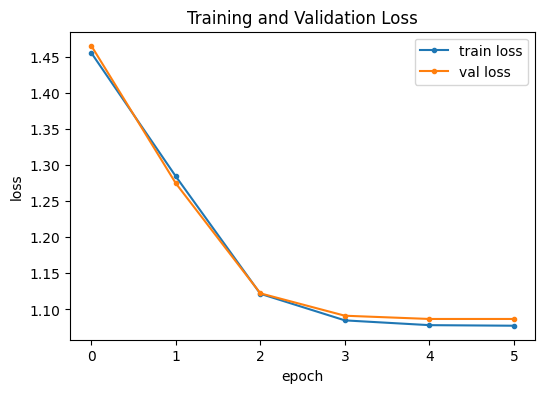

In [11]:
# create the model
model = LogisticRegressionModel(model_params).to(device)

# let's just train for a few epochs to see if the model can learn something nontrivial, even with this simple architecture
n_epochs_logistic_regression = 5

def compute_loss(dataloader, model, device):
    """Compute the average loss of the model on a dataloader without updating parameters.
    Iterates through all batches and averages loss over batches.
    Arguments:
        dataloader: DataLoader providing batches of input data and targets
        model: the model to evaluate
        device: the device to run the computation on
    Returns:
        The average loss over the dataloader
    """
    total_loss = 0.
    was_training = model.training
    model.eval()
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = batch_to_device(xb, device)
            yb = yb.to(device)
            _, loss = model(xb, yb)
            total_loss += loss.item()
    if was_training:
        model.train()
    return total_loss / len(dataloader)


# keep track of train and val loss over epochs for plotting
train_loss = [compute_loss(train_dataloader, model, device)]
val_loss = [compute_loss(val_dataloader, model, device)]

# initialize the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=model_params['learning_rate'])

# initialize the learning rate scheduler if specified
if model_params['scheduler_type'] == 'OneCycleLR':
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        **lr_scheduler_params,
        optimizer=optimizer,
        total_steps=n_epochs_logistic_regression * len(train_dataloader),
    )
elif model_params['scheduler_type'] == 'CosineAnnealingLR':
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(**lr_scheduler_params, optimizer=optimizer)
elif model_params['scheduler_type'] is None:
    scheduler = None
else:
    raise ValueError(f"Unsupported scheduler type: {model_params['scheduler_type']}")

# main training loop
total = n_epochs_logistic_regression * len(train_dataloader)
pbar = tqdm(total=total)
print(f"Initial loss before training: train: {train_loss[0]:.4f}, val: {val_loss[0]:.4f}")
# iterate over epochs
for epoch in range(n_epochs_logistic_regression):
    # iterate over batches
    for xb, yb in train_dataloader:
        xb = batch_to_device(xb, device)
        yb = yb.to(device)

        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        lr = optimizer.param_groups[0]['lr']
        pbar.update(1)
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{lr:.2e}")

    # compute the loss on the train and val sets at the end of the epoch for monitoring
    train_loss.append(compute_loss(train_dataloader, model, device))
    val_loss.append(compute_loss(val_dataloader, model, device))
    print(f"Epoch {epoch+1}/{n_epochs_logistic_regression}: train loss: {train_loss[-1]:.4f}, val loss: {val_loss[-1]:.4f}")

# plot the train and val loss curves over epochs
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(train_loss, '.-', label='train loss')
ax.plot(val_loss, '.-', label='val loss')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_title('Training and Validation Loss')
ax.legend()


In [12]:
# generate some moves
x0, y0 = val_dataset[0]
x0_device = batch_to_device(x0, device)
moves = model.generate(train_dataset, x0_device, n_new=model_params['context_length'], sample=True)
full_game = val_dataset.moves_to_gamedata(x0_device, moves)
moves = moves.cpu()

prompt_game = val_dataset.item_to_gamedata(x0)
print('Prompt:')
display(prompt_game.show())
print('Generated continuation:')
display(full_game.show(start=len(prompt_game)))


Prompt:


round,0,1,2,3,4,5,6,7
player 0,📄,🪨,✂️,📄,✂️,✂️,✂️,✂️
player 1,✂️,🪨,🪨,📄,📄,🪨,✂️,✂️
winner,1,0,1,0,-1,1,0,0
total 0,98,98,97,97,100,99,99,99
total 1,234,234,237,237,236,239,239,239


Generated continuation:


round,8,9,10,11,12,13,14,15
player 0,🪨,✂️,📄,✂️,✂️,📄,🪨,🪨
player 1,📄,✂️,✂️,✂️,📄,✂️,✂️,✂️
winner,1,0,1,0,-1,1,-1,-1
total 0,98,98,97,97,100,99,102,105
total 1,242,242,245,245,244,247,246,245


## 5. Intro to transformers and attention

From Karpathy's Let's build GPT from scratch, in code, spelled out
https://www.youtube.com/watch?v=kCc8FmEb1nY
(more lessons from Karpathy here https://karpathy.ai/zero-to-hero.html)

In [13]:
# toy example illustrating how matrix multiplication can be used for a "weighted aggregation"
B,T,C = 4,8,2 # batch size, sequence length, feature dimension
x = torch.randn(B,T,C)

# We want x[b,t] = mean_{i<=t} x[b,i]

# version 1: slow loop
xbow1 = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1] # (t,C)
        xbow1[b,t] = torch.mean(xprev, 0)
        
print('x[0]:\n', x[0])
print('xbow1[0]:\n', xbow1[0])

# version 2: using matrix multiply for a weighted aggregation
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T,T)) # set some weights, for now all the same
wei = wei.masked_fill(tril == 0, float('-inf')) # mask out the upper triangle so we only attend to current and past positions
print('wei (pre-softmax):\n', wei)
wei = F.softmax(wei, dim=-1) # normalize 
print('wei (after softmax):\n', wei)
xbow2 = wei @ x
assert torch.allclose(xbow1, xbow2), "matrix multiply version should match the loop version"


x[0]:
 tensor([[-2.0243,  1.4325],
        [ 0.3198, -0.8291],
        [-0.2657, -0.3154],
        [ 0.8577, -0.2628],
        [-0.7575,  0.1124],
        [-0.3988,  1.1847],
        [ 0.0676,  1.0904],
        [-0.2474,  0.7635]])
xbow1[0]:
 tensor([[-2.0243,  1.4325],
        [-0.8522,  0.3017],
        [-0.6567,  0.0960],
        [-0.2781,  0.0063],
        [-0.3740,  0.0275],
        [-0.3781,  0.2204],
        [-0.3145,  0.3447],
        [-0.3061,  0.3970]])
wei (pre-softmax):
 tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])
wei (after softmax):
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000

Illustrations from https://jalammar.github.io/illustrated-transformer/

The query, key, and value matrices:

![query, key, value](https://jalammar.github.io/images/t/self-attention-matrix-calculation.png)

Attention weights:

![self-attention](https://jalammar.github.io/images/t/self-attention-matrix-calculation-2.png)


Text(0, 0.5, 'time')

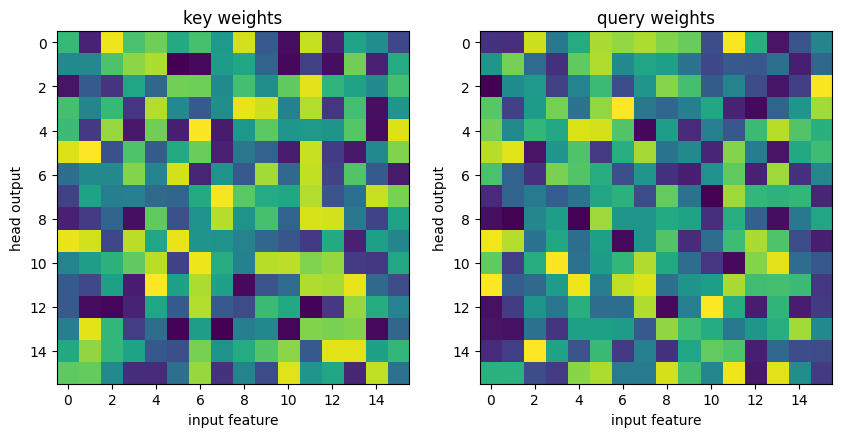

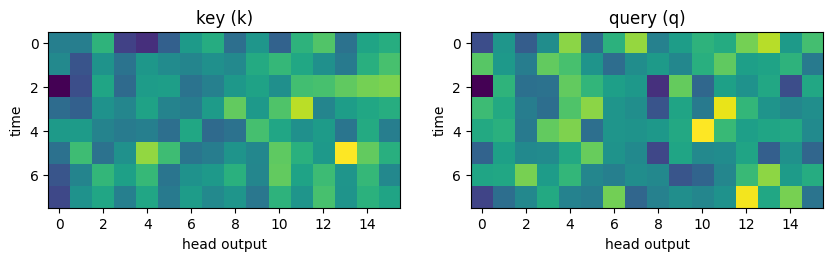

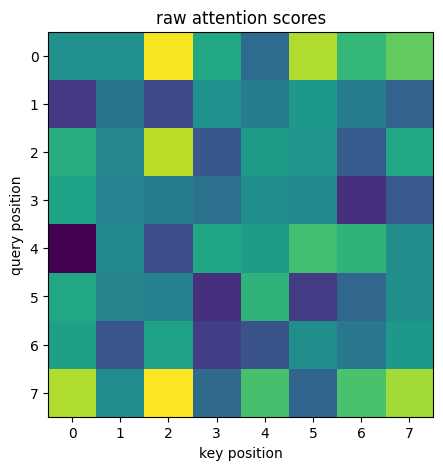

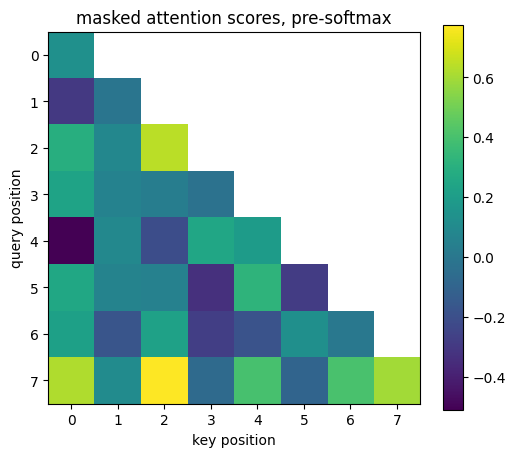

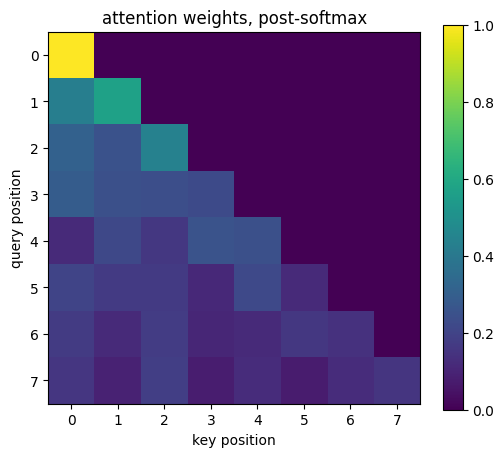

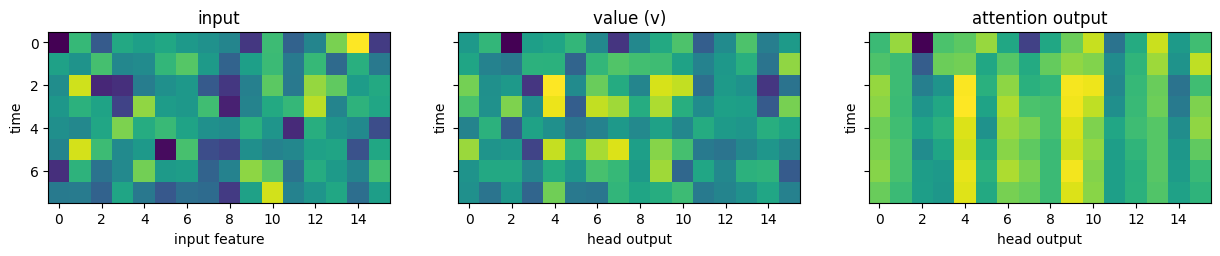

In [14]:
# another toy example with weights that depend on self attention
B,T,C = 4,8,16 # batch size, sequence length, feature dimension
x = torch.randn(B,T,C)

d_head = C

# randomly initialized linear maps for query and key, defines the space in which we compute similarity for attention
key = nn.Linear(C, d_head, bias=False)
query = nn.Linear(C, d_head, bias=False)
fig,ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(key.weight.detach().cpu().numpy())
ax[0].set_title('key weights')
ax[0].set_xlabel('input feature'); ax[0].set_ylabel('head output')
ax[1].imshow(query.weight.detach().cpu().numpy())
ax[1].set_title('query weights')
ax[1].set_xlabel('input feature'); ax[1].set_ylabel('head output')

# multiply
k = key(x)   # (B,T,d_head)
q = query(x) # (B,T,d_head)

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(k[0].detach().cpu().numpy())
ax[0].set_title('key (k)')
ax[0].set_xlabel('head output'); ax[0].set_ylabel('time')
ax[1].imshow(q[0].detach().cpu().numpy())
ax[1].set_title('query (q)')
ax[1].set_xlabel('head output'); ax[1].set_ylabel('time')

# compute dot product between query and key at each position, to get the raw attention scores
# (B, T, d_head) @ (B, d_head, T) -> (B, T, T)
# dim 1 corresponds to query position and dim 2 corresponds to key position
wei = q @ k.transpose(-2, -1) * d_head**-0.5 # (B,T,T) raw attention scores for each query position attending to each key position

fig, ax = plt.subplots(figsize=(6,5))
ax.imshow(wei[0].detach().cpu().numpy())
ax.set_title('raw attention scores')
ax.set_xlabel('key position'); ax.set_ylabel('query position')

# mask out the upper triangle so we only attend to current and past positions
tril = torch.tril(torch.ones(T, T))
wei = wei.masked_fill(tril == 0, float('-inf'))
fig, ax = plt.subplots(figsize=(6,5))
him = ax.imshow(wei[0].detach().cpu().numpy())
# colorbar
fig.colorbar(him, ax=ax)
ax.set_title('masked attention scores, pre-softmax');
ax.set_xlabel('key position'); ax.set_ylabel('query position')

# normalize the attention scores to get the attention weights
wei = F.softmax(wei, dim=-1)
fig, ax = plt.subplots(figsize=(6,5))
him = ax.imshow(wei[0].detach().cpu().numpy())
# colorbar
fig.colorbar(him, ax=ax)
ax.set_title('attention weights, post-softmax')
ax.set_xlabel('key position'); ax.set_ylabel('query position')

# apply the weighting to values instead of x, to get the full attention mechanism
value = nn.Linear(C, d_head, bias=False)
v = value(x) # (B,T,d_head)
out = wei @ v # (B,T,T) @ (B,T,d_head) -> (B,T,d_head) weighted aggregation of values at each position according to attention weights
ncols = [x.shape[-1], v.shape[-1], out.shape[-1]]   # e.g. [D, d_head, d_head]
fig, ax = plt.subplots(1, 3, figsize=(15,5), sharey=True,
                       gridspec_kw={'width_ratios': ncols})
ax[0].imshow(x[0].detach().cpu().numpy())
ax[0].set_title('input')
ax[0].set_xlabel('input feature'); ax[0].set_ylabel('time')
ax[1].imshow(v[0].detach().cpu().numpy())
ax[1].set_title('value (v)')
ax[1].set_xlabel('head output'); ax[1].set_ylabel('time')
ax[2].imshow(out[0].detach().cpu().numpy())
ax[2].set_title('attention output')
ax[2].set_xlabel('head output'); ax[2].set_ylabel('time')

Notes:

- Attention is a **communication mechanism**. Can be seen as nodes in a directed graph looking at each other and aggregating information with a weighted sum from all nodes that point to them, with data-dependent weights.
- There is no notion of space. Attention simply acts over a set of vectors. This is why we need to positionally encode tokens.
- Each example across batch dimension is of course processed completely independently and never "talk" to each other
- **Self-attention** just means that the keys and values are produced from the same source as queries.
- "Scaled" attention additional divides wei by 1/sqrt(head_size). This makes it so when input Q,K are unit variance, wei will be unit variance too and Softmax will stay diffuse and not saturate too much. Illustration below

### Define an attention head module

Text(0, 0.5, 'time')

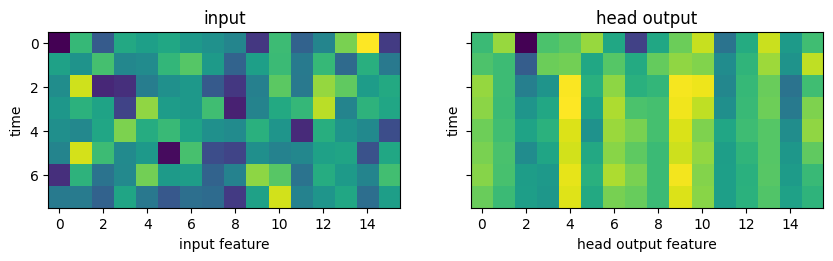

In [15]:
class Head(nn.Module):
    """one head of self-attention"""

    def __init__(self, d_head, d_embed, context_length, dropout=0.0):
        super().__init__()
        self.key = nn.Linear(d_embed, d_head, bias=False)
        self.query = nn.Linear(d_embed, d_head, bias=False)
        self.value = nn.Linear(d_embed, d_head, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(context_length, context_length)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out
    
head = Head(d_head=d_head,d_embed=C,context_length=T)

# set the weights to the weights we already defined for the toy example, so we can verify the head reproduces the same output
with torch.no_grad():
    head.key.weight.copy_(key.weight)
    head.query.weight.copy_(query.weight)
    head.value.weight.copy_(value.weight)

out = head(x)

ncols = [x.shape[-1], out.shape[-1]] 
fig, ax = plt.subplots(1, 2, figsize=(10,5), sharey=True, gridspec_kw={'width_ratios': ncols})
ax[0].imshow(x[0].detach().cpu().numpy())
ax[0].set_title('input')
ax[0].set_xlabel('input feature'); ax[0].set_ylabel('time')
ax[1].imshow(out[0].detach().cpu().numpy())
ax[1].set_title('head output')
ax[1].set_xlabel('head output feature'); ax[1].set_ylabel('time')

### Equivalent PyTorch code

Text(0, 0.5, 'time')

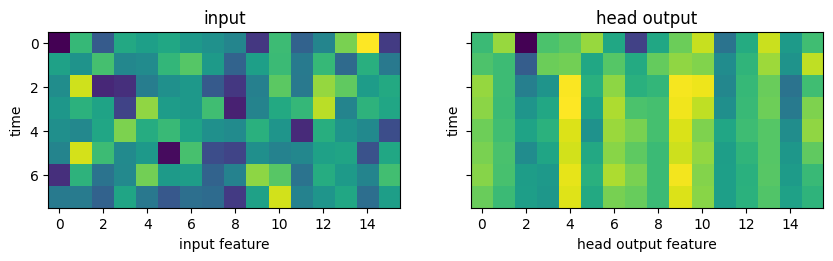

In [16]:
# compare to torch's built-in multi-head attention for verification
mha = nn.MultiheadAttention(embed_dim=C, num_heads=1, bias=False, batch_first=True)

# copy the toy weights so the module reproduces the same output as the hand-written head
with torch.no_grad():
    mha.in_proj_weight.copy_(torch.cat([query.weight, key.weight, value.weight], dim=0))  # rows = [q; k; v]
    mha.out_proj.weight.copy_(torch.eye(C))   # identity -> no output projection (match the bare head)

causal = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)   # True = blocked
out, attn = mha(x, x, x, attn_mask=causal, need_weights=True)         # out: (B,T,C), attn: (B,T,T), inputs are value, key, query, all = x

ncols = [x.shape[-1], out.shape[-1]]
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True, gridspec_kw={'width_ratios': ncols})
ax[0].imshow(x[0].detach().cpu().numpy())
ax[0].set_title('input'); ax[0].set_xlabel('input feature'); ax[0].set_ylabel('time')
ax[1].imshow(out[0].detach().cpu().numpy())
ax[1].set_title('head output'); ax[1].set_xlabel('head output feature'); ax[1].set_ylabel('time')

### Attention is position invariant

Text(0, 0.5, 'time')

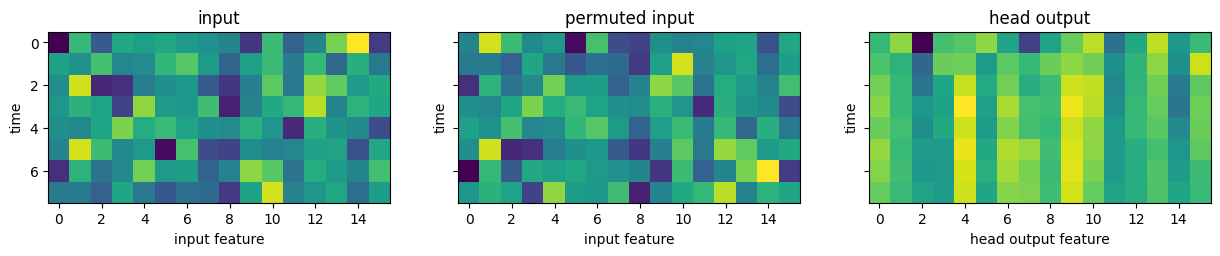

In [17]:
# randomly permute x along the time dimension
perm = torch.randperm(T)
x_perm = x[:, perm, :]

# copy the toy weights so the module reproduces the same output as the hand-written head
with torch.no_grad():
    mha.in_proj_weight.copy_(torch.cat([query.weight, key.weight, value.weight], dim=0))  # rows = [q; k; v]
    mha.out_proj.weight.copy_(torch.eye(C))   # identity -> no output projection (match the bare head)

causal = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)   # True = blocked
# out: (B,T,C), attn: (B,T,T), inputs are value = x_perm, key = x_perm, query = x
out, attn = mha(x_perm, x_perm, x, attn_mask=causal, need_weights=True)         

ncols = [x.shape[-1], x_perm.shape[-1], out.shape[-1]]
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, gridspec_kw={'width_ratios': ncols})
ax[0].imshow(x[0].detach().cpu().numpy())
ax[0].set_title('input'); ax[0].set_xlabel('input feature'); ax[0].set_ylabel('time')
ax[1].imshow(x_perm[0].detach().cpu().numpy())
ax[1].set_title('permuted input'); ax[1].set_xlabel('input feature'); ax[1].set_ylabel('time')
ax[2].imshow(out[0].detach().cpu().numpy())
ax[2].set_title('head output'); ax[2].set_xlabel('head output feature'); ax[2].set_ylabel('time')

### Other stuff in a transformer layer

So far we have **one attention head**. A real transformer wraps that in a few more pieces.

**Multi-headed attention**

![Multi-headed attention](https://jalammar.github.io/images/t/transformer_multi-headed_self-attention-recap.png)

From [The illustrated transformer](https://jalammar.github.io/illustrated-transformer/)

- Train **many** attention heads in parallel, each with its own Q/K/V projections.
- With `n_head` heads, each head works in `d_embed / n_head` dimensions. 
- Each head can specialize (e.g. "what did I play last round?" vs "did I just win?").
- **Concatenate** their outputs, then combine with one linear layer.

```
for i in range(n_head):
    head[i] = Head(x, Wq[i], Wk[i], Wv[i])
```
where each weight matrix `Wq[i]`, `Wk[i]`, `Wv[i]` are shape `(d_embed, d_embed / n_head)`

The heads are concatenated and mixed by a linear layer
```
xa = concat([Head(x,Wq[i],Wk[i],Wv[i]) for i in range(n_head)]) @ Wo
```

**Feed-forward network (MLP)**

![MLP and residual connections](https://miro.medium.com/v2/resize:fit:720/format:webp/1*8lAtTYcAgw5nBII5kdpFBg.png)

From [Mastering LLama — Understanding Residual Connection](https://medium.com/@hugmanskj/mastering-llama-understanding-residual-connection-447b5e85c355)

- After attention *mixes information across time*, a per-position MLP *computes on it*:
```
xa = MLP(x + xa)
```
where the MLP consists of `Linear(d_embed → 4·d_embed) → ReLU → Linear(4·d_embed → d_embed)`.
- This is applied independently at every position; the `4×` hidden width is the convention.
- This is where the nonlinear "thinking" happens — attention alone is mostly linear mixing.

**Residual connections**

- Each sublayer adds its input back: `x = x + xa`.
- Gives gradients a clean path through many layers, so deep stacks train.

**Layer normalization**

- Apply LayerNorm at various points to normalize each token's features to keep activations well-scaled.
**TODO change to pre-norm**
```
x = LayerNorm(x + MultiHeadAttention(x))   # mix across time  (+ residual)
x = LayerNorm(x + MLP(x))                  # compute per token (+ residual)
```
**Positional encoding**

- Attention is **permutation-invariant** — by itself it can't tell round 1 from round 5.
- So we inject position info before the blocks: **learned** (a trainable vector per
  position), **sinusoidal** (fixed `sin`/`cos`), or **RoPE** (rotate Q/K by position).
- For this fixed context window, the model below uses a **learned positional embedding table**.


## 6. Train a Transformer

In [18]:
# define a transformer model using PyTorch's built in TransformerEncoder module

class TransformerModel(RPSMixin, nn.Module):
    """Causal transformer over per-round features plus player embeddings -> next-round move logits."""
    def __init__(self, p):
        super().__init__()

        # the context length is needed to define the positional embedding and the causal mask for attention
        self.context_length = p['context_length']
        
        # player embedding: goes from the chosen self-player id index -> d_embed-dim vector.
        # equivalent to making a one-hot encoder and multiplying by a weight matrix.
        self.player_emb = nn.Embedding(p['n_player_ids'], p['d_embed'])
        
        # project the round features into the transformer's shared d_embed space
        self.round_proj = nn.Linear(self.round_feature_dim(), p['d_embed'])
        
        # project the position indices (0, 1, ..., context_length-1) into d_embed-dim vectors and add to the input as a positional signal
        self.pos_emb = nn.Embedding(p['context_length'], p['d_embed'])

        # transformer layer: multi-head self attention + MLP, with residual connections and layer norm.
        layer = nn.TransformerEncoderLayer(
            d_model=p['d_embed'], nhead=p['n_head'], dim_feedforward=4 * p['d_embed'],
            dropout=p['dropout'], activation='relu',
            batch_first=True, norm_first=True)
        
        # stack multiple layers to increase the capacity of the model
        self.encoder = nn.TransformerEncoder(layer, num_layers=p['n_layer'])
        
        # final layer norm
        self.ln_f = nn.LayerNorm(p['d_embed'])
        
        # output head: projects the transformer output at each position to the logits for the next move prediction
        self.head = nn.Linear(p['d_embed'], p['d_output'])

    def forward(self, x, targets=None):

        # single examples come in as (T, ...); training batches come in as (B, T, ...).
        squeezed = x['moves'].dim() == 3
        if squeezed:
            x = {k: v.unsqueeze(0) if torch.is_tensor(v) else v for k, v in x.items()}

        # build the per-round feature vector, player id
        self_player_id, round_features = self._stack_features(x)

        # project the round features
        B, T, _ = round_features.shape
        round_proj = self.round_proj(round_features) # (B,T,d_embed)

        # project the self player id and expand to add to each round in the sequence
        player_proj = self.player_emb(self_player_id).unsqueeze(1).expand(-1, T, -1) # (B,1,d_embed) -> (B,T,d_embed), same for every round in the sequence

        # Add a learned position code so the model can tell round 0 from round 7.
        assert T <= self.context_length, f"sequence length must be <= {self.context_length}, got {T}"
        pos = torch.arange(T, device=round_features.device)
        pos_proj = self.pos_emb(pos) # (T, d_embed), same for every example in the batch

        # add the three components together to get the input to the transformer: projected round features + player embedding + positional embedding
        h = round_proj + player_proj + pos_proj.unsqueeze(0)

        # mask the future
        mask = torch.triu(torch.full((T, T), float('-inf'), device=round_features.device), diagonal=1)
        
        # pass through the transformer layers
        h = self.encoder(h, mask=mask)
        
        # final layer norm
        h = self.ln_f(h)
        
        # project to get the logits for the next move prediction at each position
        logits = self.head(h)

        # if targets are provided, compute the cross-entropy loss between the logits and the targets
        loss = None
        if targets is not None:
            if targets.dim() == 2:
                targets = targets.unsqueeze(0)
            C = logits.shape[-1]
            loss = F.cross_entropy(logits.reshape(-1, C), targets.reshape(-1, C))

        if squeezed:
            logits = logits.squeeze(0)

        return logits, loss


In [ ]:
# create the transformer model    
model = TransformerModel(model_params).to(device)


# keep track of the train and val loss over epochs for plotting
train_loss = [compute_loss(train_dataloader, model, device)]
val_loss = [compute_loss(val_dataloader, model, device)]

# initialize the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=model_params['learning_rate'], weight_decay=model_params['weight_decay'])

# initialize the learning rate scheduler if specified
if model_params['scheduler_type'] == 'OneCycleLR':
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        **lr_scheduler_params,
        optimizer=optimizer,
        total_steps=model_params['n_epochs'] * len(train_dataloader),
    )
elif model_params['scheduler_type'] == 'CosineAnnealingLR':
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(**lr_scheduler_params, optimizer=optimizer)
elif model_params['scheduler_type'] is None:
    scheduler = None
else:
    raise ValueError(f"Unsupported scheduler type: {model_params['scheduler_type']}")

# main training loop
total = model_params['n_epochs'] * len(train_dataloader)
pbar = tqdm(total=total)
print(f"Initial loss before training: train: {train_loss[0]:.4f}, val: {val_loss[0]:.4f}")
# iterate over epochs
for epoch in range(model_params['n_epochs']):
    # iterate over batches
    for xb, yb in train_dataloader:
        xb = batch_to_device(xb, device)
        yb = yb.to(device)

        # call the model to get loss
        logits, loss = model(xb, yb)

        # gradient descent step
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        
        # update learning rate
        if scheduler is not None:
            scheduler.step()

        lr = optimizer.param_groups[0]['lr']
        pbar.update(1)
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{lr:.2e}")

    # compute the loss on the train and val sets at the end of the epoch for monitoring
    train_loss.append(compute_loss(train_dataloader, model, device))
    val_loss.append(compute_loss(val_dataloader, model, device))
    print(f"Epoch {epoch+1}/{model_params['n_epochs']}: train loss: {train_loss[-1]:.4f}, val loss: {val_loss[-1]:.4f}")

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(train_loss, label='train loss')
ax.plot(val_loss, label='val loss')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_title('Training and Validation Loss')
ax.legend()


/home/bransonk@hhmi.org/miniforge3/envs/tmp-data-format/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  0%|          | 0/14700 [00:00<?, ?it/s]

Initial loss before training: train: 1.2138, val: 1.1918
Epoch 1/30: train loss: 1.0760, val loss: 1.0900
Epoch 2/30: train loss: 1.0579, val loss: 1.0776
Epoch 3/30: train loss: 1.0011, val loss: 1.0510
Epoch 4/30: train loss: 0.9589, val loss: 1.0246
Epoch 5/30: train loss: 0.9347, val loss: 1.0171


## 6. Does it actually win? Transformer vs. two baselines

Three predictors, all judged on held-out throws:
- **Order-1 bigram** — a 3×3 table of P(next | last move). The honest "just count it" baseline.
- **Order-2 oracle** — a 3×3×3 table of P(next | last *two* moves). Because our hidden rule is order-2, this is the **Bayes-optimal ceiling**. (In a real setting you wouldn't know to build this — the model has to *discover* it.)
- **The transformer.**

Since we play `beats(prediction)`, **win-rate equals prediction accuracy.** Random play wins 1/3 of the time; that's the line to beat.

In [ ]:
def bigram_table(s):
    c = np.ones((3,3))
    for a,b in zip(s[:-1], s[1:]): c[a,b]+=1
    return c / c.sum(1, keepdims=True)

def oracle_table(s):
    c = np.ones((3,3,3))
    for a,b,d in zip(s[:-2], s[1:-1], s[2:]): c[a,b,d]+=1
    return c / c.sum(2, keepdims=True)

BG = bigram_table(seq[:n]); OR = oracle_table(seq[:n])

@torch.no_grad()
def tf_predict(hist):
    ctx = torch.tensor(hist[-block_size:], dtype=torch.long, device=device)[None]
    return int(model(ctx)[0][0, -1].argmax())

def bg_predict(hist): return int(BG[hist[-1]].argmax())
def or_predict(hist): return ROCK if len(hist) < 2 else int(OR[hist[-2], hist[-1]].argmax())

def winrate(s, predict_fn):
    wins = sum(predict_fn(s[:i]) == s[i] for i in range(2, len(s)))
    return wins / (len(s) - 2)

model.eval()
sample = seq[n:n+2500]
rates = {
    'random (1/3)':      1/3,
    'order-1 bigram':    winrate(sample, bg_predict),
    'transformer':       winrate(sample, tf_predict),
    'order-2 oracle\n(ceiling)': winrate(sample, or_predict),
}
plt.figure(figsize=(7,3.5))
bars = plt.bar(list(rates), list(rates.values()),
               color=['#999','#e67e22','#8e44ad','#2c3e50'])
plt.axhline(1/3, ls='--', c='k', lw=1); plt.ylabel('win rate'); plt.ylim(0,1)
for b,v in zip(bars, rates.values()): plt.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}', ha='center')
plt.title(f"Win rate vs the opponent  (MODE='{MODE}')"); plt.tight_layout(); plt.show()
print({k: round(v,3) for k,v in rates.items()})

**Read the bars.**

- With `MODE='markov'`: all three predictors land on the *same* number. The 3×3 table is already optimal, so attention buys nothing. Say this out loud to students — transformers are not automatically better.
- With `MODE='patterned'`: the order-1 bigram falls apart (it can't see the order-2 tell), while the transformer climbs to meet the order-2 oracle. It **discovered the right look-back length on its own** — no one told it the dependency was 2 steps deep.

## 7. Did it learn the *rule* (not just the win rate)?

Because we wrote the generator, we know the exact next-move distribution for each of the 9 possible `(prev2, prev1)` contexts. We compare that ground truth to what the trained model predicts in each context (estimated by bucketing its predictions over held-out data). If the heatmaps match, the model recovered our hidden rule — including the tell on the diagonal `(X,X)` contexts.

In [ ]:
def truth_dist(a, b):
    p = np.full(3, P_NOISE/3)
    if MODE == 'patterned' and a == b:
        p[(b+1)%3] += (1-P_NOISE)
    else:
        p[b]       += (1-P_NOISE)*P_REPEAT
        p[(b+2)%3] += (1-P_NOISE)*(1-P_REPEAT)
    return p

# model's empirical P(next | prev2, prev1)
model_mat = np.zeros((9,3)); truth_mat = np.zeros((9,3)); labels=[]
buckets = {(a,b):[] for a in range(3) for b in range(3)}
with torch.no_grad():
    s = seq[n:n+4000]
    for i in range(2, len(s)):
        ctx = torch.tensor(s[max(0,i-block_size):i], dtype=torch.long, device=device)[None]
        buckets[(int(s[i-2]), int(s[i-1]))].append(F.softmax(model(ctx)[0][0,-1], -1).cpu().numpy())
for r,(a,b) in enumerate([(a,b) for a in range(3) for b in range(3)]):
    model_mat[r] = np.mean(buckets[(a,b)], 0) if buckets[(a,b)] else 0
    truth_mat[r] = truth_dist(a,b)
    labels.append(f'{SYM[a]}{SYM[b]}')

fig, ax = plt.subplots(1,2, figsize=(9,4.2))
for a_, M, title in [(ax[0], truth_mat, 'GROUND TRUTH'), (ax[1], model_mat, 'WHAT THE MODEL LEARNED')]:
    im = a_.imshow(M, cmap='magma', vmin=0, vmax=1, aspect='auto')
    a_.set_xticks(range(3)); a_.set_xticklabels(SYM); a_.set_yticks(range(9)); a_.set_yticklabels(labels)
    a_.set_xlabel('P(next move)'); a_.set_ylabel('context (prev2, prev1)'); a_.set_title(title)
    for r in range(9):
        for c in range(3): a_.text(c, r, f'{M[r,c]:.2f}', ha='center', va='center',
                                   color='white' if M[r,c]<0.6 else 'black', fontsize=8)
plt.tight_layout(); plt.show()
print("Diagonal rows (same symbol twice) are the 'tell' — note the model puts ~0.93 on the counter-move.")

## 8. A peek at attention (optional)

Attention in a 2-layer, 4-head model isn't a clean window into "the rule," so treat this as a peek, not proof. We feed a sequence that ends in a double (e.g. `…✂️✂️`) and show where the final position attends. With the tell active, the model should lean on the last one or two throws.

In [ ]:
probe = np.array([ROCK,PAPER,SCISSORS,ROCK,PAPER,ROCK,SCISSORS,PAPER,ROCK,PAPER,SCISSORS,SCISSORS], dtype=np.int64)
with torch.no_grad():
    _ = model(torch.tensor(probe, dtype=torch.long, device=device)[None])
att = model.blocks[0].sa.heads[0].last_att[0].cpu().numpy()  # layer 0, head 0
plt.figure(figsize=(5.5,4.5))
plt.imshow(att, cmap='Blues', aspect='auto')
plt.xticks(range(len(probe)), [SYM[m] for m in probe]); plt.yticks(range(len(probe)), [SYM[m] for m in probe])
plt.xlabel('attends to (key)'); plt.ylabel('from (query)'); plt.colorbar(label='attention weight')
plt.title('Layer 0, Head 0 — note the last row (…✂️✂️ → ?)'); plt.tight_layout(); plt.show()

## 9. Play against it

Run `play(rounds=15)` to play live in Colab — type `r`/`p`/`s`. The model predicts your next throw from your history and plays the counter. It only adapts within the fixed weights it learned; it is **not** retraining on you in real time.

> This is the doorway to the real research problem: a live human is **non-stationary** (they react to losing), so strong RPS bots keep an *online* predictor and the game becomes a moving target. Online-training a transformer on a handful of live throws works poorly — that's why production bots lean on fast count-based predictors. Turning this into an online, outcome-conditioned learner is the natural capstone.

In [ ]:
def play(rounds=15):
    hist, score = [], {'you':0, 'model':0, 'tie':0}
    key = {'r':ROCK, 'p':PAPER, 's':SCISSORS}
    for _ in range(rounds):
        pred = tf_predict(hist) if hist else ROCK   # predict your move
        mv   = beats(pred)                          # play its counter
        raw  = input("Your move [r/p/s]: ").strip().lower()
        if raw not in key: print("  (use r/p/s)"); continue
        you = key[raw]
        if   you == beats(mv): score['you']  += 1; res = 'you win'
        elif mv  == beats(you): score['model']+= 1; res = 'model wins'
        else: score['tie'] += 1; res = 'tie'
        print(f"  you {SYM[you]}  vs  model {SYM[mv]}  ->  {res}   "
              f"(running: you {score['you']} / model {score['model']} / tie {score['tie']})")
        hist.append(you)
    print('\nFinal:', score)

# play(15)   # <- uncomment to play

# Non-interactive demo: let the *synthetic human* play so the notebook runs end-to-end.
demo = gen_sequence(400, seed=7)
w = sum(beats(tf_predict(demo[:i])) == beats(demo[i]) and tf_predict(demo[:i])==demo[i] for i in range(2,len(demo)))
print(f"Auto-demo vs the synthetic human: model wins {w}/{len(demo)-2} = {w/(len(demo)-2):.0%} of rounds")

## 10. Exercises (and the bridge back to your data)

1. **Make attention earn nothing.** Set `MODE='markov'`, rerun, and confirm the transformer ties the bigram. *Why?*
2. **Deepen the tell.** Change the rule to depend on `prev3` (e.g. "after the same move three times, switch"). Watch the order-2 oracle now fail too, while the transformer keeps up — and `block_size` starts to matter.
3. **Crank the noise.** Raise `P_NOISE` and watch every predictor compress toward 1/3. There is no beating true randomness — the whole reason the optimal RPS strategy is uniform play.
4. **Go interactive.** Feed the model the *outcome* of each round (win/lose/tie) as extra tokens and make the opponent genuinely win-stay/lose-shift. Now you have a 6-token language and a non-stationary speaker.
5. **Swap the tokens.** This is the punchline for the course: replace the RPS stream with **MoSeq behavioral syllables** or **binned spike IDs** and *nothing about the model changes*. The RPS mind-reader and a "language model of mouse behavior" are the same program with a different vocabulary.